In [1]:
import time
from pathlib import Path
from urllib.request import urlretrieve

import cv2
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision

# Download model (only once)
model_path = Path("pose_landmarker.task")
if not model_path.exists():
    model_url = (
        "https://storage.googleapis.com/mediapipe-models/pose_landmarker/"
        "pose_landmarker_full/float16/1/pose_landmarker_full.task"
    )
    print("Downloading model...", model_url)
    urlretrieve(model_url, model_path)

# Pose connections (simplified skeleton)
POSE_CONNECTIONS = [
    (11, 13), (13, 15),  # left arm
    (12, 14), (14, 16),  # right arm
    (11, 12),            # shoulders
    (11, 23), (12, 24),  # torso
    (23, 24),            # hips
    (23, 25), (25, 27),  # left leg
    (24, 26), (26, 28),  # right leg
]

# Setup model
options = vision.PoseLandmarkerOptions(
    base_options=mp_python.BaseOptions(model_asset_path=str(model_path)),
    running_mode=vision.RunningMode.VIDEO,
    num_poses=1,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
    min_tracking_confidence=0.5,
)

cap = cv2.VideoCapture(0)

if not cap.isOpened():
    raise RuntimeError("Could not open webcam")

with vision.PoseLandmarker.create_from_options(options) as landmarker:
    print("Press 'q' to quit")

    while True:
        ok, frame = cap.read()
        if not ok:
            break

        frame = cv2.flip(frame, 1)
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb)
        timestamp_ms = int(time.time() * 1000)

        result = landmarker.detect_for_video(mp_image, timestamp_ms)
        output = frame.copy()

        if result.pose_landmarks:
            h, w = output.shape[:2]
            pose = result.pose_landmarks[0]

            # Draw points
            points = []
            for lm in pose:
                x = int(lm.x * w)
                y = int(lm.y * h)
                points.append((x, y))
                cv2.circle(output, (x, y), 4, (0, 255, 255), -1)

            # Draw skeleton
            for a, b in POSE_CONNECTIONS:
                cv2.line(output, points[a], points[b], (0, 200, 0), 2)

            # Example: Detect hands up 🙌
            left_hand_up = pose[15].y < pose[11].y
            right_hand_up = pose[16].y < pose[12].y

            if left_hand_up and right_hand_up:
                cv2.putText(output, "HANDS UP", (10, 40),
                            cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

        cv2.imshow("Pose Detection (MediaPipe Tasks)", output)

        if cv2.waitKey(1) & 0xFF == ord("q"):
            break

cap.release()
cv2.destroyAllWindows()

Press 'q' to quit


(-0.5, 1023.5, 682.5, -0.5)

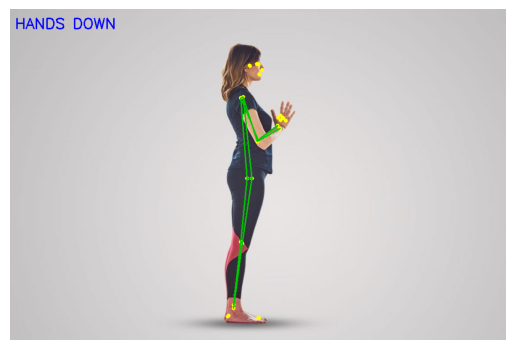

In [5]:

import time
from pathlib import Path
from urllib.request import urlretrieve

import cv2
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
from matplotlib import pyplot as plt
# Input / output image paths
image_path = Path("C:\\Users\\LENOVO\\OneDrive\\Documents\\1PYTHON\\7_AI_ML\\pose.jpeg")          # change to your file

# Use IMAGE mode for single-frame inference
# Ensure model_path exists in this cell/session
if "model_path" not in globals():
    model_path = Path("pose_landmarker.task")

if not model_path.exists():
    model_url = (
        "https://storage.googleapis.com/mediapipe-models/pose_landmarker/"
        "pose_landmarker_full/float16/1/pose_landmarker_full.task"
    )
    print("Downloading model...", model_url)
    urlretrieve(model_url, model_path)

# Pose connections (simplified skeleton)
POSE_CONNECTIONS = [
    (11, 13), (13, 15),  # left arm
    (12, 14), (14, 16),  # right arm
    (11, 12),            # shoulders
    (11, 23), (12, 24),  # torso
    (23, 24),            # hips
    (23, 25), (25, 27),  # left leg
    (24, 26), (26, 28),  # right leg
]

image_options = vision.PoseLandmarkerOptions(
    base_options=mp_python.BaseOptions(model_asset_path=str(model_path)),
    running_mode=vision.RunningMode.IMAGE,
    num_poses=1,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
)

# Read image
image_bgr = cv2.imread(str(image_path))
if image_bgr is None:
    raise FileNotFoundError(f"Image not found: {image_path}")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)

with vision.PoseLandmarker.create_from_options(image_options) as landmarker:
    result = landmarker.detect(mp_image)

output = image_bgr.copy()

if result.pose_landmarks:
    h, w = output.shape[:2]
    pose = result.pose_landmarks[0]

    points = []
    for lm in pose:
        x = int(lm.x * w)
        y = int(lm.y * h)
        points.append((x, y))
        cv2.circle(output, (x, y), 4, (0, 255, 255), -1)

    for a, b in POSE_CONNECTIONS:
        cv2.line(output, points[a], points[b], (0, 200, 0), 2)

    hand_up = pose[15].y < pose[11].y and pose[16].y < pose[12].y
    if hand_up:
        cv2.putText(output, "HANDS UP", (10, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    else:
        cv2.putText(output, "HANDS DOWN", (10, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.axis("off")


In [ ]:

import time
from pathlib import Path
from urllib.request import urlretrieve

import cv2
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
from matplotlib import pyplot as plt
# Input / output image paths
image_path = Path("C:\\Users\\LENOVO\\OneDrive\\Documents\\1PYTHON\\7_AI_ML\\pose.jpeg")          # change to your file

# Use IMAGE mode for single-frame inference
# Ensure model_path exists in this cell/session
if "model_path" not in globals():
    model_path = Path("pose_landmarker.task")

if not model_path.exists():
    model_url = (
        "https://storage.googleapis.com/mediapipe-models/pose_landmarker/"
        "pose_landmarker_full/float16/1/pose_landmarker_full.task"
    )
    print("Downloading model...", model_url)
    urlretrieve(model_url, model_path)

# Pose connections (simplified skeleton)
POSE_CONNECTIONS = [
    (11, 13), (13, 15),  # left arm
    (12, 14), (14, 16),  # right arm
    (11, 12),            # shoulders
    (11, 23), (12, 24),  # torso
    (23, 24),            # hips
    (23, 25), (25, 27),  # left leg
    (24, 26), (26, 28),  # right leg
]

image_options = vision.PoseLandmarkerOptions(
    base_options=mp_python.BaseOptions(model_asset_path=str(model_path)),
    running_mode=vision.RunningMode.IMAGE,
    num_poses=1,
    min_pose_detection_confidence=0.5,
    min_pose_presence_confidence=0.5,
)

# Read image
image_bgr = cv2.imread(str(image_path))
if image_bgr is None:
    raise FileNotFoundError(f"Image not found: {image_path}")

image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)

with vision.PoseLandmarker.create_from_options(image_options) as landmarker:
    result = landmarker.detect(mp_image)

output = image_bgr.copy()

if result.pose_landmarks:
    h, w = output.shape[:2]
    pose = result.pose_landmarks[0]

    points = []
    for lm in pose:
        x = int(lm.x * w)
        y = int(lm.y * h)
        points.append((x, y))
        cv2.circle(output, (x, y), 4, (0, 255, 255), -1)

    for a, b in POSE_CONNECTIONS:
        cv2.line(output, points[a], points[b], (0, 200, 0), 2)

    hand_up = pose[15].y < pose[11].y and pose[16].y < pose[12].y
    if hand_up:
        cv2.putText(output, "HANDS UP", (10, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    else:
        cv2.putText(output, "HANDS DOWN", (10, 40),
                    cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)

plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.axis("off")
